# 08_优化算法-牛顿方法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里和大家来聊一个非常有趣的数值方法：牛顿法。

**牛顿方法**（Newton's Method），又称**牛顿-拉夫森方法**，是一种用来求解非线性方程的数值方法，特别适用于找到一个函数的根（即找到 $f(x) = 0$的解）。它是基于函数的导数来逐步逼近方程解的。

### 数学定义

假设你有一个非线性方程 $f(x) = 0$，你希望找到这个方程的根。

牛顿方法的迭代公式：


$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$


其中：

- $x_n$是第 $n$ 次迭代的值。
- $f(x_n)$是函数在 $x_n$的函数值。
- $f'(x_n)$是函数在 $x_n$的导数值。

从初始猜测 $x_0$开始，每次迭代计算新的 $x$值，逐步逼近方程的根。

其实很容易理解，牛顿方法可以理解为一种“智能猜答案”的过程。假设你有一个问题，比如一个抛物线（函数曲线）和 $x$轴的交点是什么（也就是函数的根）。你不知道准确的答案，但你可以随便猜一个值 $x_0$，接着用这个方法逐步改进你的猜测，让答案越来越接近真实的解。

具体来说，牛顿方法通过利用函数的切线来调整猜测。假设你从某个位置 $x_0$开始，如果你知道函数在 $x_0$点的值和斜率（导数），你可以用这个信息来画出一条切线。切线就是一条直线，它在 $x_0$处与函数曲线相切。然后，你看这条切线在哪个位置与 $x$轴相交，这个交点会给你一个新的 $x_1$。通过这样的过程，你不断调整自己的猜测，最终得到接近正确答案的结果。

简单总结：

1. 随便猜个数字（初始值）。
2. 用这个数字算函数值和导数，得出一个新猜测。
3. 新猜测更接近正确答案。
4. 重复几次，你的猜测就会非常接近方程的根。

牛顿方法通常收敛得非常快，但它对初始值要求较高，可能会失败或者发散，如果初始值离根太远或者导数为零。

## 理论基础

**牛顿方法的核心思想是**：利用一个初始猜测点，通过不断地利用该点的切线逼近根，从而找到方程的根。具体来说，它利用了泰勒级数展开的思想，只保留了一级展开（即线性近似），通过线性逼近来找到非线性方程的根。

假设你有一个连续可微的函数 $f(x)$，希望找到它的根（即 $f(x) = 0$的解）。假设我们从某个 $x_0$开始猜测，这时函数在 $x_0$处的切线方程是：


$$
y = f(x_0) + f'(x_0)(x - x_0)
$$


这里 $f'(x_0)$是 $f(x)$在 $x_0$处的导数值，切线是函数曲线的线性近似。

为了找到函数的根，切线和 $x$轴的交点可以作为新的近似值。因为切线在 $x$轴上的交点是 $y = 0$，所以我们可以令上面的切线方程 $y = 0$，解出新的 $x$值：


$$
0 = f(x_0) + f'(x_0)(x - x_0)
$$


这可以整理为：


$$
x = x_0 - \frac{f(x_0)}{f'(x_0)}
$$


得到新的迭代公式：


$$
x_1 = x_0 - \frac{f(x_0)}{f'(x_0)}
$$


这一公式表明，我们通过 $x_0$的切线找到一个新的 $x_1$，这个 $x_1$会比 $x_0$更接近根。然后，我们可以用同样的方法在 $x_1$处继续迭代，重复这一过程，直到我们找到满足一定精度的根。

### 牛顿方法收敛性

牛顿方法通常收敛得非常快，尤其当初始猜测值 $x_0$足够接近根时。它的收敛速度是**二次收敛**，这意味着每次迭代误差大约会以平方的速度减小。

数学上，如果初始猜测足够好，牛顿方法的误差 $e_n$满足：


$$
e_{n+1} \approx C \cdot e_n^2
$$


其中 $C$是某个常数，$e_n = |x_n - x^*|$，$x^*$是根的精确值。也就是说，误差会迅速减小。

然而，牛顿方法对初始点的选择非常敏感，如果初始点选择得不好（比如离根太远或者函数导数在某些点接近 0），可能会导致算法发散或失效。

### 牛顿方法的算法流程

以下是牛顿方法的详细算法流程，逐步说明如何从初始猜测值开始，逐步逼近方程的根。

**第一步：选择初始猜测值** $x_0$

选择一个初始点 $x_0$，这通常是对方程根的初步猜测。初始点的选择非常重要，它影响到算法是否能够成功找到根以及收敛速度。

**第二步：计算函数值和导数值**

计算函数在初始猜测点 $x_0$的值 $f(x_0)$和导数值 $f'(x_0)$。

$f(x_0)$表示函数在点 $x_0$处的值。

$f'(x_0)$表示函数在点 $x_0$处的导数（即切线的斜率）。

**第三步：检查导数是否为零**

如果导数 $f'(x_0) = 0$，意味着在此点处切线是水平的（平行于 $x$轴），无法进行进一步的迭代（因为分母为 0）。此时需要重新选择初始点或者使用其他方法。

**第四步：更新新的猜测值**

通过牛顿迭代公式更新新的猜测值 $x_1$：


$$
x_1 = x_0 - \frac{f(x_0)}{f'(x_0)}
$$


**第五步：检查收敛性**

检查新的猜测值 $x_1$是否足够接近真实解。这通常通过以下两种方式之一进行：

1. **误差检查**：判断新旧两个迭代值的差距是否足够小，即：  
$|x_1 - x_0| < \epsilon$  
其中 $\epsilon$是设定的一个很小的容差值，表示所要求的精度。如果满足该条件，算法收敛，输出当前的 $x_1$作为近似解。
2. **函数值检查**：判断函数值 $f(x_1)$是否足够接近 0，即：  
$|f(x_1)| < \epsilon$  
如果函数值足够接近 0，认为当前解 $x_1$已经非常接近根，可以停止迭代。

**第六步：重复迭代**

如果没有满足收敛条件，将新的 $x_1$作为下一个迭代的初始值，继续迭代：

- 计算 $f(x_1)$和 $f'(x_1)$。
- 使用公式更新：$x_2 = x_1 - \frac{f(x_1)}{f'(x_1)}$
- 重复上述步骤，直到满足收敛条件。

### 牛顿法完整过程

1. **选择初始值** $x_0$。
2. **计算函数值** $f(x_n)$和导数值 $f'(x_n)$。
3. **检查导数是否为 0**：如果 $f'(x_n) = 0$，则无法继续，选择新的初始值或使用其他方法。
4. **更新迭代值**：使用迭代公式更新新的 $x_{n+1}$：$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$
5. **检查收敛性**：判断 $|x_{n+1} - x_n|$或 $|f(x_{n+1})|$是否小于预设的容差 $\epsilon$。如果满足条件，输出 $x_{n+1}$作为近似解。
6. **重复**：如果未收敛，继续下一次迭代。

这个流程重复执行，直到找到一个足够精确的根。

### 注意项

- 牛顿方法对初始点 $x_0$非常敏感。如果初始点选择不好，可能导致算法发散，无法找到根。
- 如果在某个点处 $f'(x_n) = 0$，无法进行进一步迭代，因此要避免这种情况。
- 牛顿方法适合那些**函数光滑且导数变化平稳**的场景，如果函数的导数变化剧烈，可能会导致收敛困难。

通过这些步骤，牛顿方法能有效地找到方程的根，特别是当初始猜测点接近真实根时，收敛速度非常快。

## 完整案例

这里的案例，包含数据分析和可视化。将虚拟数据集应用于牛顿方法，并绘制两张复杂的图形来展示收敛过程和误差的变化，大家更容易理解。

### 案例说明

1. 我们将求解一个非线性方程 f(x)=x3−2x2−5=0f(x) = x^3 - 2x^2 - 5 = 0。
2. 使用牛顿方法求解此方程，并分析牛顿法的迭代过程。

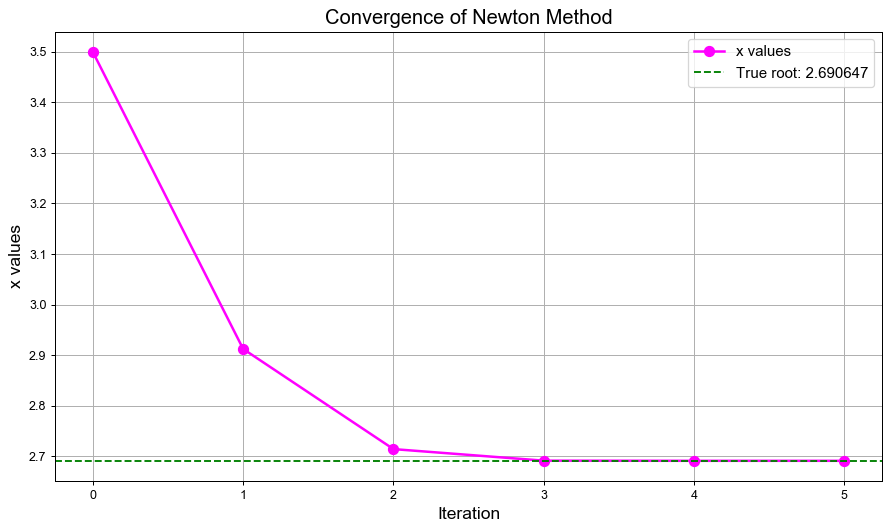

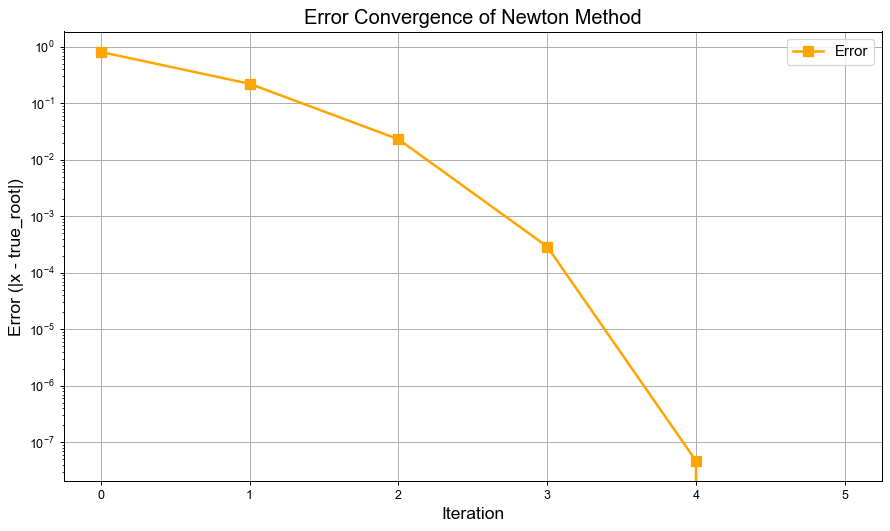

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 牛顿方法函数定义
def newton_method(f, f_prime, x0, tol=1e-6, max_iter=100):
    """
    使用牛顿法求解 f(x) = 0，返回根和收敛过程中的 x 值序列。
    
    参数:
    f: 目标函数
    f_prime: 目标函数的导数
    x0: 初始猜测值
    tol: 允许的误差范围
    max_iter: 最大迭代次数
    
    返回:
    x_vals: 牛顿法迭代过程中 x 值的列表
    """
    x = x0
    x_vals = [x]  # 用于存储迭代过程中的x值
    
    for i in range(max_iter):
        fx = f(x)
        fpx = f_prime(x)
        
        # 防止导数为0的情况，避免分母为0
        if abs(fpx) < 1e-10:
            print("导数过小，无法继续迭代。")
            break
        
        # 更新x值
        x_new = x - fx / fpx
        x_vals.append(x_new)
        
        # 检查是否满足精度要求
        if abs(x_new - x) < tol:
            break
        
        x = x_new
        
    return x_vals

# 定义非线性方程 f(x) = x^3 - 2x^2 - 5
def f(x):
    return x**3 - 2*x**2 - 5

# 定义导数 f'(x)
def f_prime(x):
    return 3*x**2 - 4*x

# 设置初始猜测值
x0 = 3.5

# 使用牛顿方法进行求解，获取迭代过程中的 x 值序列
x_vals = newton_method(f, f_prime, x0)

# 计算对应的误差（相对于最终解）
true_root = x_vals[-1]  # 最终解
errors = [abs(x - true_root) for x in x_vals]

# ---- 图1：收敛过程 ----
plt.figure(figsize=(10, 6))
iterations = np.arange(len(x_vals))

plt.plot(iterations, x_vals, '-o', color='magenta', label='x values', markersize=8, linewidth=2)
plt.title('Convergence of Newton Method', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('x values', fontsize=14)
plt.grid(True)
plt.axhline(y=true_root, color='green', linestyle='--', label=f'True root: {true_root:.6f}')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()

# ---- 图2：误差收敛 ----
plt.figure(figsize=(10, 6))
plt.plot(iterations, errors, '-s', color='orange', label='Error', markersize=8, linewidth=2)
plt.title('Error Convergence of Newton Method', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Error (|x - true_root|)', fontsize=14)
plt.yscale('log')  # 使用对数坐标来更好地展示误差收敛
plt.grid(True)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()

# 显示图形
plt.show()

1. **newton_method()** 函数实现了牛顿方法，能够根据函数和其导数逐步逼近方程的根。该函数优化了对导数为 0 的处理，以防止分母为 0。
2. **f(x)** 和 **f'(x)** 定义了我们要解决的非线性方程和其导数。
3. **x0 = 3.5** 设置了初始猜测值，我们从该点开始迭代。

**收敛过程图**：展示迭代过程中 xx 值的变化。图中还添加了一条水平虚线，标示出最终求解的根。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

**误差收敛图**：展示了误差随着迭代次数的变化情况，使用对数坐标系更直观地展示误差收敛情况。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

1. **收敛过程图**：展示了牛顿方法在几次迭代内快速收敛到根。
2. **误差收敛图**：展示了误差随着迭代次数快速减小，呈现二次收敛的特性，最终误差接近零。

以上，就是咱们今天给大家分享的，如何使用牛顿方法求解复杂的非线性方程，并通过可视化分析其收敛速度和误差变化。在大家的实验中，可以根据问题复杂性选择合适的初始猜测值，以获得快速收敛效果。

## 应用场景

牛顿方法主要适用于**求解非线性方程**，特别是那些可以轻松求得导数并且导数不为零的函数。

具体适用的问题类型包括：

1. **非线性方程的根**：求解 $f(x) = 0$形式的非线性方程，比如多项式方程、超越方程等。
2. **优化问题**：牛顿方法的扩展可以用于寻找函数的极值（最大值或最小值），因为求解 $f'(x) = 0$可以找到函数的驻点，扩展为多元的牛顿法可以用于无约束优化。
3. **方程组求解**：通过向量和矩阵的推广，可以用于求解非线性方程组。
4. **数值分析中的迭代求解**：在数值分析领域，牛顿方法也用于某些迭代求解问题，比如求平方根、倒数等。

### 牛顿方法的优缺点

**优点**：

1. **收敛速度快**：当初始猜测值较好时，牛顿方法具有二次收敛的性质，收敛速度非常快。每次迭代误差的平方倍减少。
2. **应用广泛**：牛顿方法可以推广到多元方程组、多维优化问题，适用范围较广。
3. **高精度**：能够通过多次迭代达到较高精度的解，只需要少量的迭代步数。

**缺点**：

1. **对初始值敏感**：初始值离真实解太远时，可能会导致迭代失败，甚至发散。
2. **需要求导数**：必须能计算函数的导数，且要求导数在迭代点附近不为零。因此，不适合那些难以求导或导数接近零的函数。
3. **局部收敛**：牛顿方法通常是局部收敛的，只有在初始猜测点靠近实际根时，才表现出快速收敛的特性。否则可能会进入无解或错误解的区域。
4. **可能无法收敛**：在某些情况下，牛顿方法可能无法收敛，例如导数为零或函数极其不规则的情况。

### 牛顿方法的运用前提条件

1. **函数是可微的**：牛顿方法需要用到函数的导数，因此要求函数在整个迭代过程中是连续可导的。
2. **初始值选择合理**：为了保证快速收敛和避免发散，初始猜测值需要合理选择，通常初始值需要足够接近实际根。
3. **导数不为零**：要求函数在迭代过程中导数 $f'(x_n) \neq 0$，否则会导致计算错误或停止迭代。
4. **函数性质良好**：函数的导数变化平缓，没有剧烈的跳变或振荡，否则牛顿法可能出现不稳定的情况。